# BiasOnDemand synthetic benchmark

Sweeps three feature-side bias types (historical / measurement / representational)
at three intensity levels each, then runs the full scikit-fair method × classifier
grid against all 9 synthetic datasets.

| Track | Parameter | low | med | high |
|---|---|---|---|---|
| historical (R) | `l_h_r` | 0.5 | 1.5 | 3.0 |
| measurement (R) | `l_m` | 0.5 | 1.0 | 2.0 |
| representational | `p_u` (with `l_r=True`) | 0.75 | 0.5 | 0.25 |

All other bias parameters are held at 0 within each track (univariate sweep).
`y == y_real` for every dataset here — only `l_m_y` (measurement bias on Y)
would create a gap, and that is intentionally out of scope for now.

### What each parameter means (and why the values are not comparable)

The three parameters live on **different scales**, so the same number means very different things across tracks.

- **`l_h_r` — historical bias on R.** Code: `R = N1 - l_h_r * A`. An additive shift of R for the unprivileged group (`A=1`), in feature-σ units. Since R drives Y directly, the same shift propagates into Y. `0.5` ≈ ½σ shift (subtle), `1.5` ≈ clearly separated groups, `3.0` ≈ near-total separation.
- **`l_m` — measurement bias on R.** R is replaced by a noisy proxy P for the unprivileged group; magnitude is the noise level (same units as R). Smaller = proxy is informative, larger = proxy is essentially noise.
- **`p_u` — representational, with `l_r=True`.** Pure probability: fraction of the unprivileged group that is **kept**. The privileged group is untouched. So `p_u=0.5` means `new_unpriv ≈ 0.5 × original_unpriv`; given BiasOnDemand's ~50/50 default split, that's roughly half the privileged group's size after undersampling.

### About `l_r=True` (informed undersampling)

`l_r=True` is **not random** undersampling. The code sorts the unprivileged group by R ascending and keeps the lowest-R fraction (size `p_u × |A=1|`); the highest-R unprivileged individuals are dropped. This is *combined* representational + selection bias: the unprivileged group is both smaller and systematically less qualified on the predictive feature R. With `l_r=False`, undersampling is essentially random — much milder. We use `True` here because it's the harder, more realistic case fairness methods are usually benchmarked against.

### Why these specific values? (anchoring to package defaults)

The grid isn't arbitrary — each track's **med** is the value `biasondemand.generate_dataset` ships as its own default, and **low** / **high** sit roughly 1/3× and 2× around it:

| track | low | **med (package default)** | high |
|---|---|---|---|
| `l_h_r` | 0.5 | **1.5** | 3.0 |
| `l_m`   | 0.5 | **1.0** | 2.0 |
| `p_u` (with `l_r=True`) | 0.75 | **0.5** | 0.25 |

For `l_h_r` and `l_m` this is direct: the package signature is `generate_dataset(..., l_h_r=1.5, l_m=1, ...)`, so `med` reproduces the maintainer-recommended baseline and the sweep widens from there.

For `p_u` the logic is different — the package default is `p_u=1` (no undersampling), so there's no "default biased level" to anchor on. We instead anchor `med=0.5` because, given BiasOnDemand's ~50/50 split on `A`, keeping half of the unprivileged group makes the two groups roughly equal in size — a natural midpoint. `low=0.75` and `high=0.25` are symmetric around it.

**Why not just use `0.5 / 1 / 2` for every track?** Two reasons:

1. The parameters live on **different scales and units** — `l_h_r` shifts a Gamma-distributed feature, `l_m` injects noise into a proxy, `p_u` is a probability — so the same numeric label would *not* make the tracks comparable. The intensity ordering (low/med/high) is what matters across tracks, not the raw value.
2. Capping `l_h_r` at 2 instead of 3 would weaken the "high" extreme. At `l_h_r=3` the two groups are nearly fully separated on R, which is exactly the regime where baseline classifiers start breaking and fairness methods earn their keep. Losing that end of the sweep would shrink the dynamic range of the benchmark.

## 1. Define the bias grid

In [1]:
from pathlib import Path

import biasondemand
import pandas as pd
import yaml

BIAS_GRID = [
    ("hist_low",  {"l_h_r": 0.5}),
    ("hist_med",  {"l_h_r": 1.5}),
    ("hist_high", {"l_h_r": 3.0}),
    ("meas_low",  {"l_m": 0.5}),
    ("meas_med",  {"l_m": 1.0}),
    ("meas_high", {"l_m": 2.0}),
    ("repr_low",  {"l_r": True, "p_u": 0.75, "l_m": 0}),
    ("repr_med",  {"l_r": True, "p_u": 0.5,  "l_m": 0}),
    ("repr_high", {"l_r": True, "p_u": 0.25, "l_m": 0}),
]

DATASETS_DIR = Path("datasets")
DIM = 1000

## 2. Generate the 9 dataset folders (raw + concat)

Two layouts:

- `datasets/raw/<name>/` — BiasOnDemand's per-fold CSVs (`X_train.csv`, `X_test.csv`,
  `y_train.csv`, `y_test.csv`, plus `*_ind_*` / `*_supp_*` / `*_real` variants).
- `datasets/concat/<name>.csv` — single readable CSV per dataset, columns
  `[*features, A, Y]`, written with `index=False`. This is what the experiment loads.

Both steps are idempotent. Set `force=True` to regenerate.

In [2]:
force = False
RAW_DIR = DATASETS_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

# biasondemand.generate_dataset hardcodes a `datasets/` prefix on the path it
# receives, so passing path=f"raw/{name}" lands the per-fold CSVs at
# datasets/raw/<name>/.
for name, kwargs in BIAS_GRID:
    folder = RAW_DIR / name
    if folder.exists() and any(folder.iterdir()) and not force:
        print(f"skip raw/{name} (exists)")
        continue
    print(f"generate raw/{name}: {kwargs}")
    biasondemand.generate_dataset(path=f"raw/{name}", dim=DIM, **kwargs)

skip raw/hist_low (exists)
skip raw/hist_med (exists)
skip raw/hist_high (exists)
skip raw/meas_low (exists)
skip raw/meas_med (exists)
skip raw/meas_high (exists)
skip raw/repr_low (exists)
skip raw/repr_med (exists)
skip raw/repr_high (exists)


In [3]:
CONCAT_DIR = DATASETS_DIR / "concat"
CONCAT_DIR.mkdir(parents=True, exist_ok=True)

# Concatenate train+test into a single CSV per dataset, written with index=False
# for readability. We pass index_col=0 on read because biasondemand's to_csv
# leaves the row index as an unnamed first column.
for name, _ in BIAS_GRID:
    out = CONCAT_DIR / f"{name}.csv"
    if out.exists() and not force:
        print(f"skip concat/{name}.csv (exists)")
        continue
    raw = RAW_DIR / name
    X = pd.concat(
        [pd.read_csv(raw / "X_train.csv", index_col=0),
         pd.read_csv(raw / "X_test.csv",  index_col=0)],
        ignore_index=True,
    )
    y = pd.concat(
        [pd.read_csv(raw / "y_train.csv", index_col=0)["Y"],
         pd.read_csv(raw / "y_test.csv",  index_col=0)["Y"]],
        ignore_index=True,
    ).astype(int)
    df = X.assign(Y=y.values)
    df.to_csv(out, index=False)
    print(f"wrote {out}  shape={df.shape}  positives={int(y.sum())}")

skip concat/hist_low.csv (exists)
skip concat/hist_med.csv (exists)
skip concat/hist_high.csv (exists)
skip concat/meas_low.csv (exists)
skip concat/meas_med.csv (exists)
skip concat/meas_high.csv (exists)
skip concat/repr_low.csv (exists)
skip concat/repr_med.csv (exists)
skip concat/repr_high.csv (exists)


## 3. Load each concatenated CSV into the custom-dataset shape

`Experiment` accepts a list of dicts of the form `{"name", "data": (X, y), "sens_attr", "priv_group"}`.
We read from `datasets/concat/<name>.csv` (already train+test combined). The sensitive
attribute column is `A`; `Experiment` does its own 5-fold CV.

In [4]:
def load_dataset(csv_path, name):
    df = pd.read_csv(csv_path)
    y = df["Y"].astype(int)
    X = df.drop(columns=["Y"])
    return {"name": name, "data": (X, y), "sens_attr": "A", "priv_group": 1}

datasets = [
    load_dataset(CONCAT_DIR / f"{name}.csv", name)
    for name, _ in BIAS_GRID
]
[(d["name"], d["data"][0].shape, int(d["data"][1].sum())) for d in datasets]

[('hist_low', (1000, 3), 481),
 ('hist_med', (1000, 3), 486),
 ('hist_high', (1000, 3), 486),
 ('meas_low', (1000, 3), 486),
 ('meas_med', (1000, 3), 486),
 ('meas_high', (1000, 3), 486),
 ('repr_low', (880, 3), 422),
 ('repr_med', (761, 3), 369),
 ('repr_high', (641, 3), 314)]

## 4. Build the Experiment

Datasets injected programmatically; everything else (methods, classifiers,
metrics, CV, audit, save) is read straight from `config.yaml`.

In [5]:
from pathlib import Path

from skfair.experimentation import Experiment

with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

Path(cfg["save"]["path"]).parent.mkdir(parents=True, exist_ok=True)

exp = Experiment(
    datasets=datasets,
    methods=cfg["methods"],
    classifiers=cfg["classifiers"],
    metrics=cfg["metrics"],
    n_splits=cfg["cv"]["n_splits"],
    random_state=cfg["cv"]["random_state"],
    stratify=cfg["cv"].get("stratify", "y"),
    audit_bias=cfg["audit"]["bias"],
    audit_fairness=cfg["audit"]["fairness"],
    save_results_csv=cfg["save"]["results_csv"],
    save_object_pkl=cfg["save"]["object_pkl"],
    save_report_html=cfg["save"]["report_html"],
    save_path=cfg["save"]["path"],
)

## 5. Run

9 datasets × 12 methods × 4 classifiers × 5 folds = 2160 fits. Outputs are saved
to `../outputs/biasondemand/biasondemand.{csv,pkl,html}` via the `save:` block of
the YAML.

In [6]:
results = exp.run(verbose=True)
results


Dataset: hist_low


  Baseline                       | LogReg  acc=0.744  spd=0.562
  Baseline                       | DecisionTree  acc=0.665  spd=0.351


  Baseline                       | SVC  acc=0.742  spd=0.367


  Baseline                       | XGBoost  acc=0.715  spd=0.454


  FairSmote                      | LogReg  acc=0.712  spd=0.151


...

/home/joao/Desktop/scikit-fair/skfair/metrics/_fairness.py:171: RuntimeWarning: No actual positives; TPR is undefined, returning 0.0.
  - true_positive_rate(y_true_p, y_pred_p)
/home/joao/Desktop/scikit-fair/skfair/metrics/_fairness.py:207: RuntimeWarning: No actual positives; TPR is undefined, returning 0.0.
  - true_positive_rate(y_true_p, y_pred_p))
/home/joao/Desktop/scikit-fair/skfair/metrics/_fairness.py:347: RuntimeWarning: No actual positives; TPR is undefined, returning 0.0.
  tpr_priv = true_positive_rate(y_true_p, y_pred_p)
/home/joao/Desktop/scikit-fair/skfair/metrics/_fairness.py:387: RuntimeWarning: No actual positives; FNR is undefined, returning 0.0.
  - false_negative_rate(y_true_p, y_pred_p)


/home/joao/Desktop/scikit-fair/skfair/metrics/_fairness.py:171: RuntimeWarning: No actual positives; TPR is undefined, returning 0.0.
  - true_positive_rate(y_true_p, y_pred_p)
/home/joao/Desktop/scikit-fair/skfair/metrics/_fairness.py:207: RuntimeWarning: No actual positives; TPR is undefined, returning 0.0.
  - true_positive_rate(y_true_p, y_pred_p))
/home/joao/Desktop/scikit-fair/skfair/metrics/_fairness.py:347: RuntimeWarning: No actual positives; TPR is undefined, returning 0.0.
  tpr_priv = true_positive_rate(y_true_p, y_pred_p)
/home/joao/Desktop/scikit-fair/skfair/metrics/_fairness.py:387: RuntimeWarning: No actual positives; FNR is undefined, returning 0.0.
  - false_negative_rate(y_true_p, y_pred_p)


/home/joao/Desktop/scikit-fair/skfair/experimentation/_runner.py:262: RuntimeWarning: Mean of empty slice
  result[m] = float(np.nanmean(vals)) if len(vals) else float("nan")


  FairMask                       | XGBoost  acc=0.735  spd=0.595


,dataset,method,classifier,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
0,hist_low,Baseline,LogReg,0.744000,0.743187,0.739953,0.725451,0.730368,4.341833,0.561732,0.364373,0.438556,-0.512740,13.869951,0.865389,1.929836,-0.364373
1,hist_low,Baseline,DecisionTree,0.665000,0.664016,0.656338,0.640335,0.647581,2.242431,0.351381,0.203448,0.263662,-0.323876,2.665819,0.875161,1.415476,-0.203448
2,hist_low,Baseline,SVC,0.742000,0.740273,0.751418,0.698432,0.721896,2.478730,0.367430,0.145364,0.218243,-0.291122,4.177322,0.866253,1.271446,-0.145364
3,hist_low,Baseline,XGBoost,0.715000,0.714843,0.701444,0.712994,0.706358,2.833210,0.453868,0.246378,0.336653,-0.426928,5.170263,0.867427,1.478145,-0.246378
4,hist_low,FairSmote,LogReg,0.712000,0.710069,0.719962,0.663080,0.687617,1.425454,0.151412,-0.074833,-0.004082,-0.066670,1.322439,0.879048,0.916624,0.074833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,repr_high,FairBalanceClassifier,XGBoost,0.723825,0.722654,0.741964,0.665540,0.700449,8.560153,0.510313,0.669448,0.488748,-0.308048,5.472488,0.701476,NaN,-0.069448
428,repr_high,FairMask,LogReg,0.786289,0.786367,0.786307,0.780287,0.781078,NaN,0.599563,0.785285,0.552611,-0.319938,NaN,0.757634,NaN,-0.185285
429,repr_high,FairMask,DecisionTree,0.726986,0.726796,0.723165,0.716436,0.719081,5.811321,0.575036,0.720705,0.551725,-0.382745,3.818182,0.701105,NaN,-0.120705
430,repr_high,FairMask,SVC,0.780027,0.780455,0.765964,0.796109,0.779393,NaN,0.627047,0.801105,0.583621,-0.366136,NaN,0.749598,NaN,-0.201105


## 6. Summary tables

In [7]:
report = exp.to_report()
tables = report.summary_tables()
for name, df in tables.items():
    print(f"--- {name} ---")
    display(df)

--- hist_high ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.7563,0.7565,0.7418,0.7645,0.7525,5.0229,0.6195,0.3937,0.4760,-0.5583,14.7893,0.8890,1.9557,-0.3937
DisparateImpactRemover,0.7513,0.7515,0.7361,0.7604,0.7474,5.4430,0.6335,0.4305,0.5024,-0.5743,16.3273,0.8967,2.1492,-0.4305
FAWOS,0.7563,0.7565,0.7418,0.7645,0.7525,5.0229,0.6195,0.3937,0.4760,-0.5583,14.7893,0.8890,1.9557,-0.3937
FairBalanceClassifier,0.7090,0.7081,0.7138,0.6739,0.6920,2.1869,0.3230,0.0783,0.1475,-0.2166,2.2867,0.8757,1.1939,-0.0783
FairMask,0.7412,0.7406,0.7403,0.7202,0.7295,2.6481,0.4097,0.1346,0.2180,-0.3015,3.3077,0.8750,1.2303,-0.1346
FairOversampling,0.7205,0.7230,0.6773,0.8107,0.7373,2.2989,0.4416,0.1582,0.2796,-0.4009,2.8472,0.9707,1.2453,-0.1582
FairSmote,0.6888,0.6876,0.6960,0.6456,0.6685,1.6870,0.2211,-0.0413,0.0376,-0.1166,1.5760,0.8628,0.9516,0.0413
FairwayRemover,0.7505,0.7517,0.7223,0.7938,0.7557,4.0411,0.5740,0.3130,0.4193,-0.5255,10.5689,0.9153,1.6919,-0.3130
HeterogeneousFOS,0.6955,0.6944,0.7006,0.6569,0.6771,1.9159,0.2763,0.0297,0.1028,-0.1758,1.9101,0.8694,1.0858,-0.0297


--- hist_low ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.7165,0.7156,0.7123,0.6943,0.7016,2.9741,0.4336,0.2399,0.3143,-0.3887,6.4708,0.8686,1.5237,-0.2399
DisparateImpactRemover,0.7155,0.7149,0.7076,0.7015,0.7025,3.2391,0.4591,0.2906,0.3457,-0.4008,6.7928,0.8953,1.7564,-0.2906
FAWOS,0.7165,0.7156,0.7123,0.6943,0.7016,2.9741,0.4336,0.2399,0.3143,-0.3887,6.4708,0.8686,1.5237,-0.2399
FairBalanceClassifier,0.6905,0.6885,0.6991,0.6397,0.6648,1.6475,0.2095,0.0274,0.0816,-0.1357,1.6166,0.8851,1.0919,-0.0274
FairMask,0.7075,0.7051,0.7214,0.6454,0.6788,1.9418,0.2646,0.0603,0.1294,-0.1986,2.4036,0.8561,1.1242,-0.0603
FairOversampling,0.7052,0.7067,0.6768,0.7463,0.7084,1.9228,0.3245,0.1001,0.1948,-0.2895,2.3589,0.9113,1.1726,-0.1001
FairSmote,0.6885,0.6860,0.7033,0.6241,0.6573,1.3792,0.1355,-0.0675,-0.0021,-0.0633,1.2578,0.8679,0.9134,0.0675
FairwayRemover,0.7085,0.7082,0.6979,0.7042,0.6986,2.6590,0.4040,0.1935,0.2849,-0.3763,5.7244,0.8669,1.4012,-0.1935
HeterogeneousFOS,0.6878,0.6854,0.7002,0.6267,0.6584,1.5289,0.1768,-0.0188,0.0457,-0.1101,1.4838,0.8661,0.9959,0.0188


--- hist_med ---


...

,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.7551,0.7552,0.7487,0.7555,0.7506,5.9151,0.6033,0.7602,0.5667,-0.3731,4.0568,0.7229,NaN,-0.1602
DisparateImpactRemover,0.7465,0.7464,0.7448,0.7356,0.7385,6.1572,0.5789,0.7403,0.5483,-0.3563,3.3409,0.7224,NaN,-0.1403
FAWOS,0.7551,0.7552,0.7487,0.7555,0.7506,5.9151,0.6033,0.7602,0.5667,-0.3731,4.0568,0.7229,NaN,-0.1602
FairBalanceClassifier,0.7250,0.7242,0.7401,0.6806,0.7069,7.8767,0.3996,0.6340,0.3993,-0.1647,4.5935,0.8396,0.6721,-0.0340
FairMask,0.7570,0.7571,0.7525,0.7539,0.7516,5.8113,0.5991,0.7586,0.5620,-0.3653,3.8182,0.7255,NaN,-0.1586
FairOversampling,0.7208,0.7219,0.6998,0.7762,0.7304,8.3866,0.4792,0.7303,0.5000,-0.2698,5.5074,0.8734,0.8197,-0.1303
FairSmote,0.7251,0.7239,0.7454,0.6694,0.7031,5.9177,0.4061,0.6736,0.4210,-0.1685,2.9805,0.8200,NaN,-0.0736
FairwayRemover,0.7340,0.7319,0.7211,0.6519,0.6747,7.4188,0.5069,0.6552,0.4721,-0.2890,4.6850,0.6987,1.0000,-0.0552
HeterogeneousFOS,0.7192,0.7182,0.7363,0.6694,0.6992,6.5930,0.3984,0.6736,0.4201,-0.1665,4.0327,0.8206,NaN,-0.0736


--- repr_low ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.7565,0.7551,0.7610,0.7193,0.7389,27.5467,0.6566,0.6228,0.5540,-0.4852,9.4838,0.8470,6.1652,-0.6228
DisparateImpactRemover,0.7497,0.7493,0.7390,0.7388,0.7380,12.3484,0.6431,0.5943,0.5390,-0.4838,14.1858,0.8694,5.5485,-0.5943
FAWOS,0.7565,0.7551,0.7610,0.7193,0.7389,27.5467,0.6566,0.6228,0.5540,-0.4852,9.4838,0.8470,6.1652,-0.6228
FairBalanceClassifier,0.7060,0.7048,0.7019,0.6749,0.6871,2.6128,0.3298,0.2222,0.1708,-0.1194,2.0426,0.9563,1.9815,-0.2222
FairMask,0.7352,0.7341,0.7325,0.7068,0.7180,3.6522,0.4557,0.3305,0.2949,-0.2593,3.0183,0.9033,2.0693,-0.3305
FairOversampling,0.6889,0.6928,0.6439,0.7867,0.7068,2.0876,0.3759,0.2462,0.2373,-0.2283,1.7604,1.0778,1.5680,-0.2462
FairSmote,0.6761,0.6760,0.6601,0.6719,0.6651,1.5805,0.1964,0.0694,0.0262,0.0170,1.0088,1.0350,1.1693,-0.0694
FairwayRemover,0.7517,0.7525,0.7347,0.7719,0.7495,11.1038,0.5922,0.4990,0.4591,-0.4191,8.8114,0.9265,3.2702,-0.4990
HeterogeneousFOS,0.7006,0.6996,0.6932,0.6760,0.6837,2.1539,0.2915,0.1896,0.1289,-0.0682,1.4567,0.9846,1.5004,-0.1896


--- repr_med ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.7556,0.7553,0.7493,0.7486,0.7476,17.4996,0.6546,0.6726,0.5725,-0.4725,10.7182,0.7682,2.7444,-0.6726
DisparateImpactRemover,0.7565,0.7567,0.7433,0.7622,0.7513,20.9713,0.6556,0.6605,0.5671,-0.4736,13.8272,0.7802,3.1242,-0.6605
FAWOS,0.7556,0.7553,0.7493,0.7486,0.7476,17.4996,0.6546,0.6726,0.5725,-0.4725,10.7182,0.7682,2.7444,-0.6726
FairBalanceClassifier,0.7145,0.7140,0.7124,0.6958,0.7016,5.2370,0.3957,0.2731,0.2332,-0.1933,4.1043,0.8836,1.9017,-0.2731
FairMask,0.7549,0.7545,0.7518,0.7419,0.7449,14.8923,0.5911,0.5861,0.4848,-0.3835,11.5990,0.8033,2.9579,-0.5861
FairOversampling,0.6919,0.6949,0.6498,0.7933,0.7130,2.5269,0.4081,0.1780,0.2245,-0.2710,2.2177,0.9809,1.4791,-0.1780
FairSmote,0.6794,0.6795,0.6660,0.6809,0.6715,1.7807,0.2279,0.0723,0.0443,-0.0163,1.1410,1.0084,1.2342,-0.0723
FairwayRemover,0.7591,0.7592,0.7482,0.7628,0.7545,17.7895,0.6709,0.7008,0.5937,-0.4866,10.6183,0.7755,2.8270,-0.7008
HeterogeneousFOS,0.6932,0.6927,0.6867,0.6748,0.6790,3.1412,0.3227,0.1981,0.1622,-0.1263,2.2990,0.9197,1.5343,-0.1981


## 7. Trade-off and ranking plots

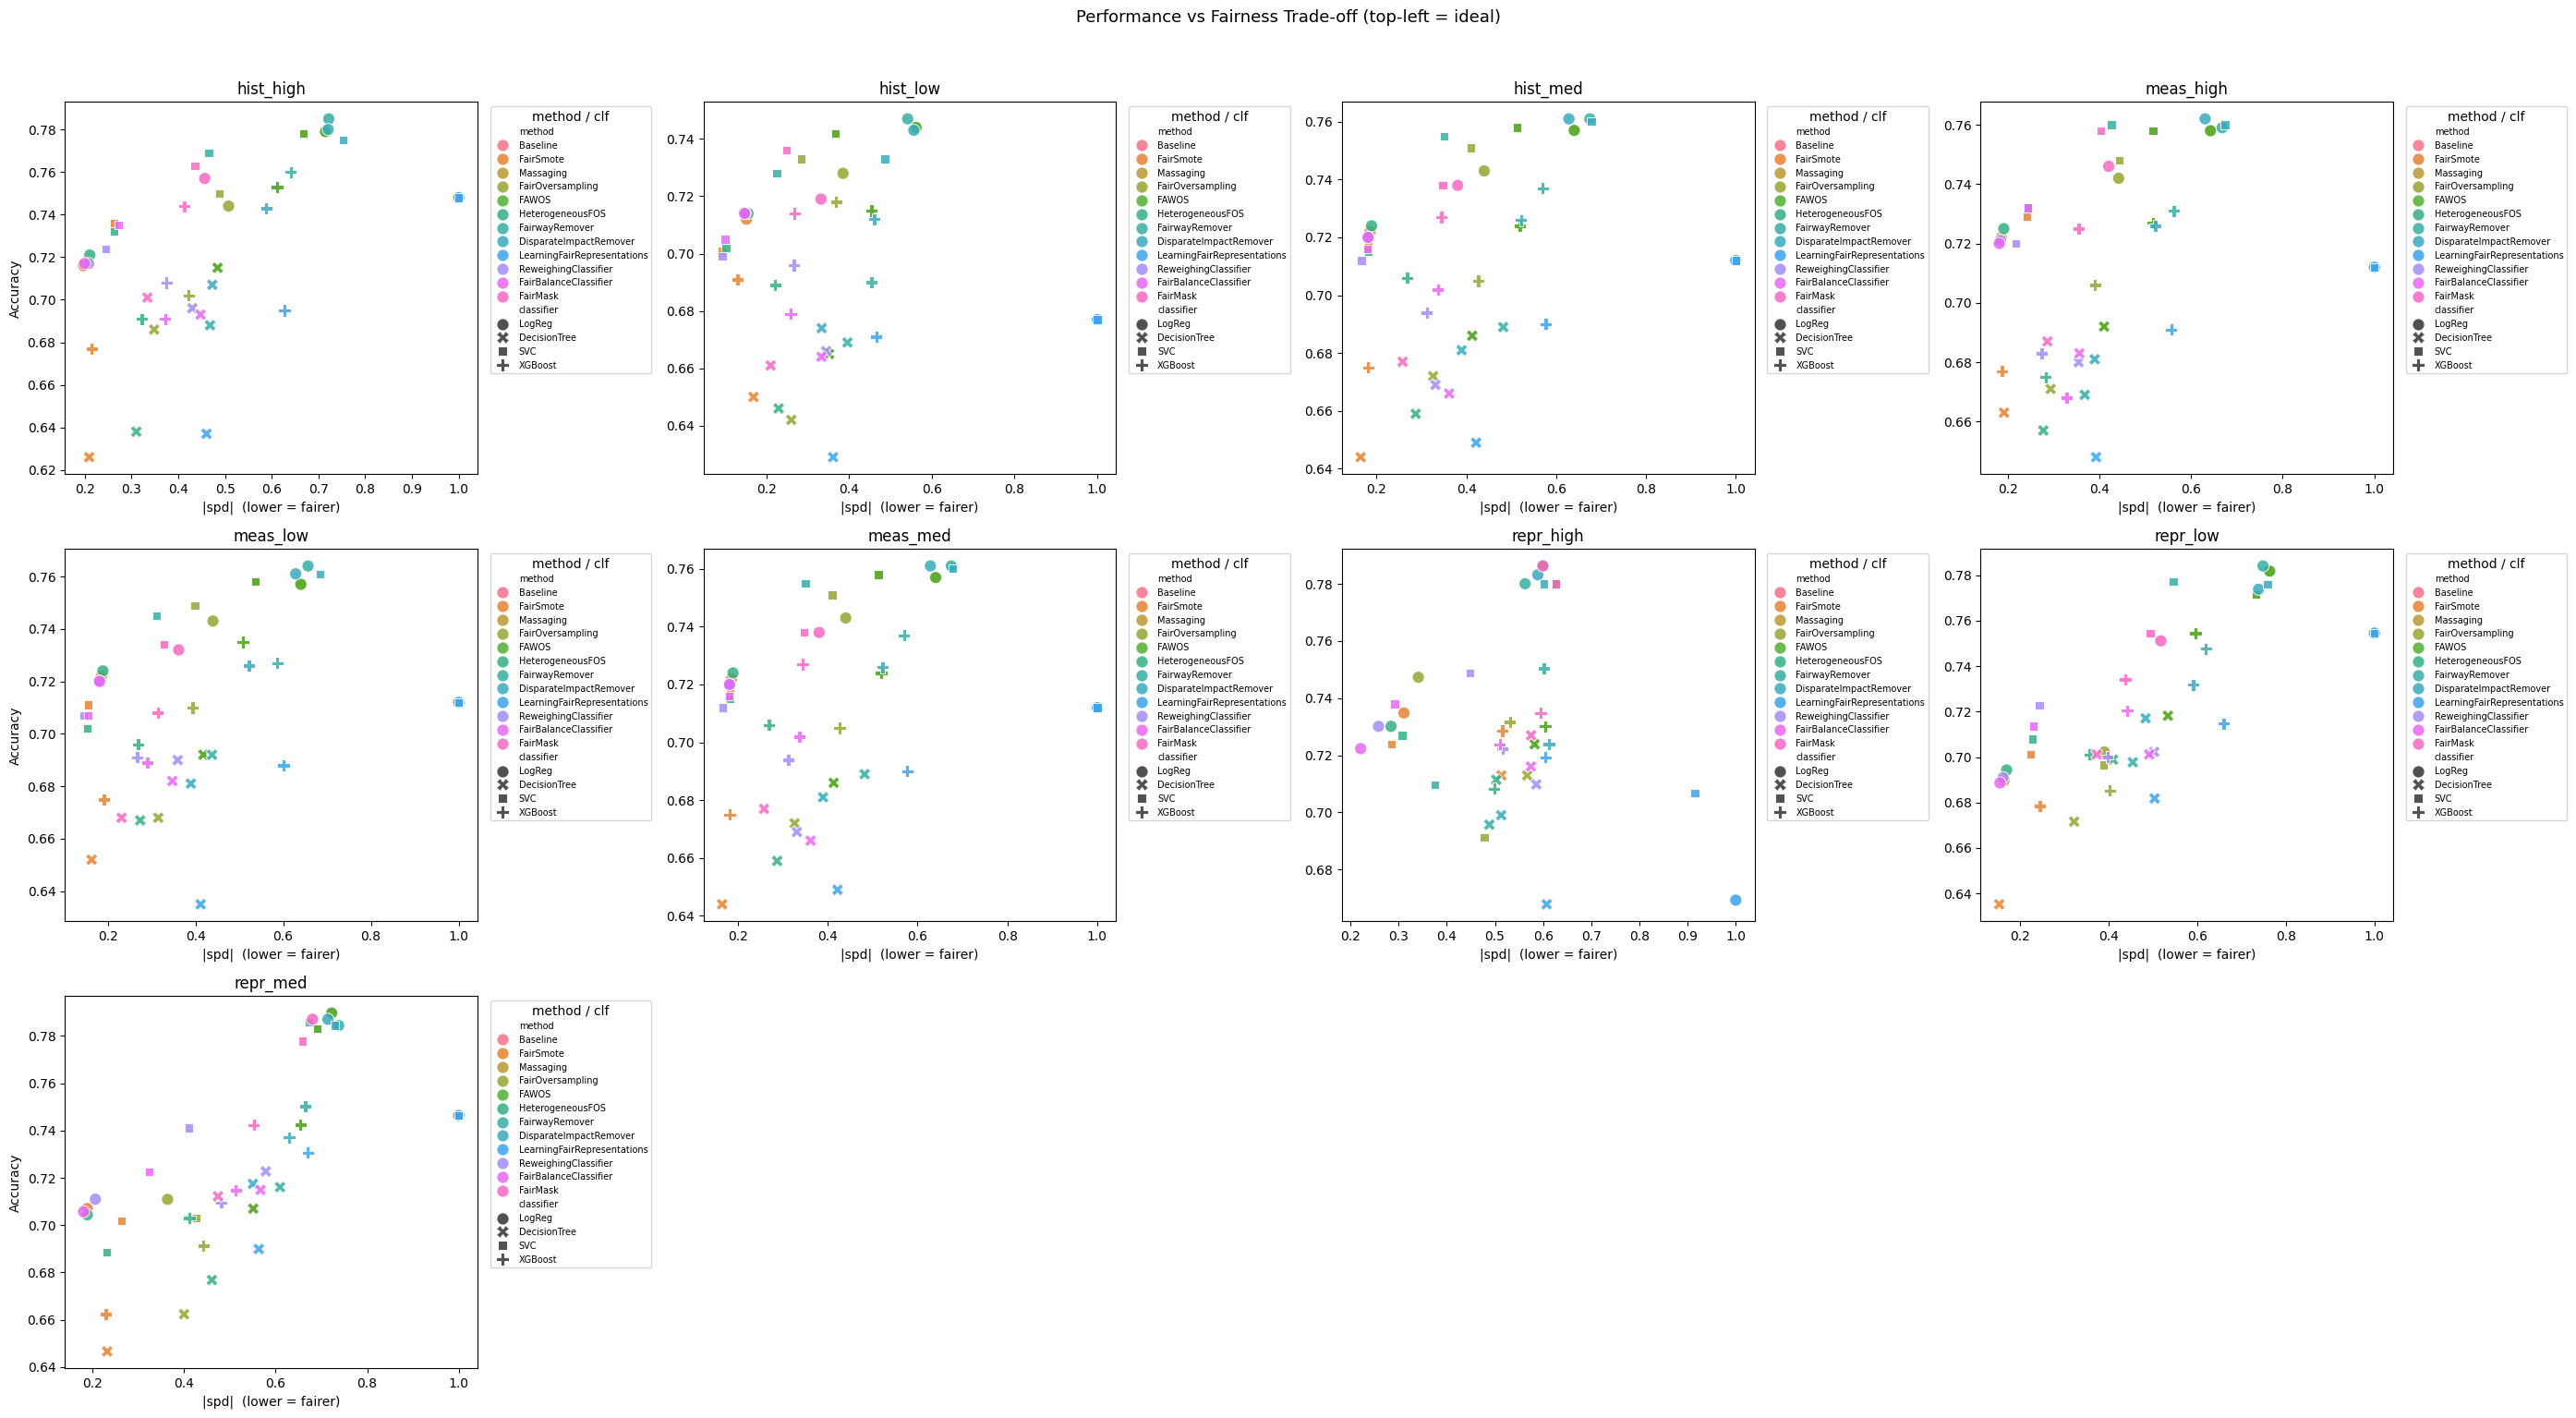

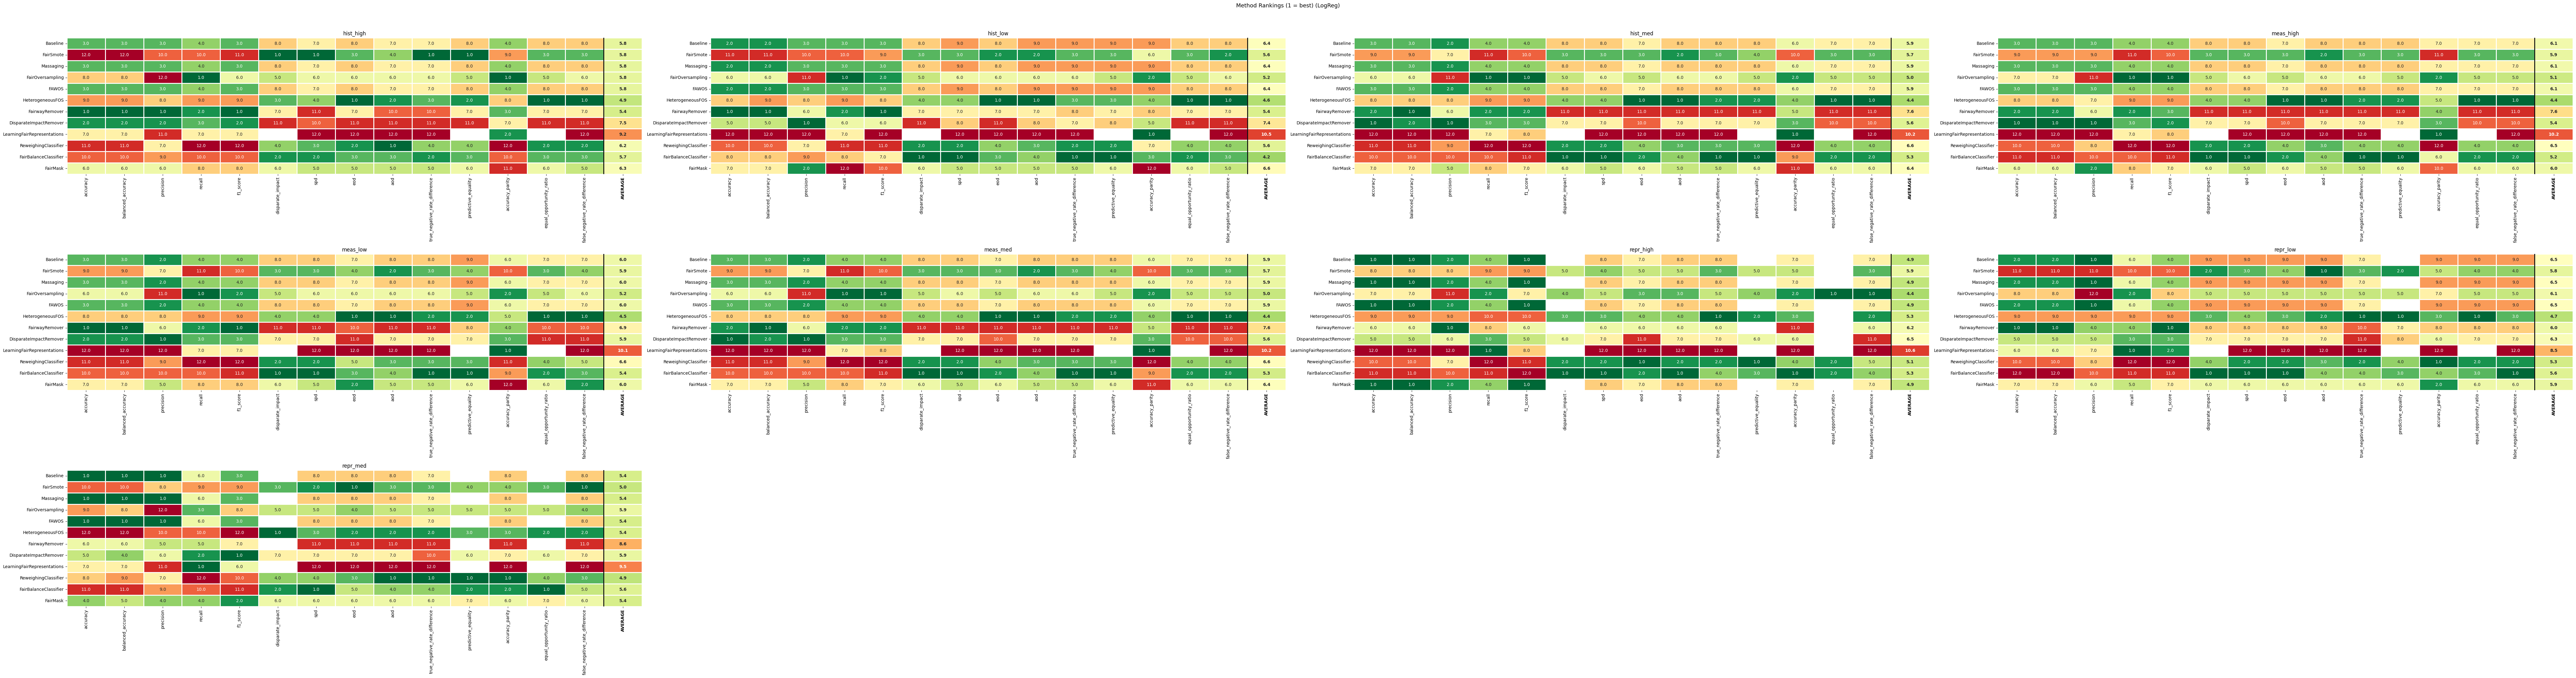

In [8]:
report.plot_tradeoff(fairness_metric="spd", performance_metric="accuracy");
report.plot_ranking(classifier="LogReg");

## 8. Per-bias-track view

Splits the dataset name into `bias_track` (hist / meas / repr) and `bias_level`
(low / med / high), then aggregates headline metrics per (method, track).
Direct answer to *which method best handles which bias type*.

In [9]:
df = results.copy()
df["bias_track"] = df["dataset"].str.split("_").str[0]
df["bias_level"] = df["dataset"].str.split("_").str[1]

df.groupby(["method", "bias_track"])[["spd", "disparate_impact", "accuracy"]].mean().round(3)

spd  disparate_impact  accuracy
method                      bias_track                                   
Baseline                    hist        0.525             3.908     0.735
                            meas        0.523             3.743     0.733
                            repr        0.638            21.075     0.756
DisparateImpactRemover      hist        0.549             4.256     0.733
                            meas        0.555             4.098     0.732
                            repr        0.626            13.795     0.751
FAWOS                       hist        0.525             3.908     0.735
                            meas        0.523             3.743     0.733
                            repr        0.638            21.075     0.756
FairBalanceClassifier       hist        0.266             1.927     0.700
                            meas        0.262             1.927     0.700
                            repr        0.375             5.242     0.715
FairMask                    hist        0.336             2.285     0.723
                            meas        0.336             2.284     0.720
                            repr        0.549             8.888     0.749
FairOversampling            hist        0.389             2.154     0.714
                            meas        0.393             2.220     0.717
                            repr        0.421             4.334     0.701
FairSmote                   hist        0.178             1.537     0.689
                            meas        0.185             1.576     0.692
                            repr        0.277             2.836     0.694
FairwayRemover              hist        0.499             3.476     0.732
                            meas        0.508             3.653     0.732
                            repr        0.590            12.004     0.748
HeterogeneousFOS            hist        0.228             1.729     0.695
                            meas        0.234             1.768     0.698
                            repr        0.338             3.963     0.704
LearningFairRepresentations hist        0.743             3.318     0.687
                            meas        0.747             3.406     0.689
                            repr        0.794            12.152     0.715
Massaging                   hist        0.525             3.908     0.735
                            meas        0.523             3.743     0.733
                            repr        0.638            21.075     0.756
ReweighingClassifier        hist        0.258             1.904     0.701
                            meas        0.248             1.863     0.701
                            repr        0.399             5.698     0.718